# Writing Attribution Prediction Model
## Can We Predict Who Someone Thinks Wrote a Text — AI or Human?

### Goal
We have a survey where participants read a text and guessed whether it was written by **AI** or a **Human**.  
We want to build a model that predicts their answer based on their **other survey responses** (demographics + opinions about AI).

### Steps
1. Load the data
2. Prepare the target variable and features
3. Explore the data (EDA)
4. Build and train the model
5. Evaluate performance
6. Analyze which features matter most

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})
print('Libraries imported successfully!')

Libraries imported successfully!


---
## Step 2: Load the Data

In [2]:
# Load the survey data
df = pd.read_excel('data/cleaned_data.xlsx')
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head(3))

Dataset: 256 rows x 21 columns


,Gender,What's Your Age?,What is your current educational status?,What is your field of study?,Do you like the writing style of Artificial Intelligence (AI)?,Which writing style gives you more trust?,What are the main advantages of using AI in writing?,Do you think AI can be relied upon in writing?,Do you feel that AI writing is sometimes repetitive or similar?,Do you think AI can convey emotions in writing?,...,How would you rate the creativity of AI-generated writing?,Does AI writing need editing?,What most distinguishes human writing?,How would you rate the clarity and writing style of this,"In your opinion, who wrote this text?",How would you rate the clarity and writing style of this 2,"In your opinion, who wrote this text? 2",Which AI tools do you use for writing?,Which writing style gives you more trust? 2,response_id
0,Male,20 - 23,University,Data Science,I somewhat like it,Both equally,"Speed in completing tasks, Helps generate ideas",Only in informal writing,Often,"Yes, to a great extent",...,3,Often,"Emotional expression, Writer’s experience and ...",Very clear with a good style,Human,Very clear with a good style,Human,"ChatGPT, Anthropic Claude, Google Gemini",Human writing,2
1,Female,20 - 23,University,Data Science,I somewhat like it,Both equally,Saving effort,In both,Sometimes,To a limited extent,...,3,Often,Personal style,Very clear with a good style,Human,Very clear with a good style,Artificial Intelligence,ChatGPT,It depends on the topic,3
2,Female,20 - 23,University,Data Science,I somewhat like it,AI writing,"Language formulation/style, Helps generate ideas",Only in formal writing,Sometimes,To a limited extent,...,4,Often,"Emotional expression, Personal style",Moderately clear,Human,Very clear with a good style,Artificial Intelligence,"ChatGPT, Google Gemini",AI writing,4


---
## Step 3: Prepare the Target Variable

Our target is the question: **"In your opinion, who wrote this text?"**  
We keep only two answers: **Human** and **Artificial Intelligence** (we remove "Not sure").

In [3]:
# Show all answers for the target question
target_col = 'In your opinion, who wrote this text?'
print('All answers:')
print(df[target_col].value_counts())

# Keep only Human and AI (remove "Not sure")
df_model = df[df[target_col].isin(['Human', 'Artificial Intelligence'])].copy()

# Convert to numbers: Human = 0, AI = 1
df_model['target'] = (df_model[target_col] == 'Artificial Intelligence').astype(int)

print(f'\nAfter filtering:')
print(f'  Human (0): {sum(df_model["target"] == 0)}')
print(f'  AI    (1): {sum(df_model["target"] == 1)}')
print(f'  Total:     {len(df_model)}')

All answers:
In your opinion, who wrote this text?
Human                      122
Artificial Intelligence    102
Not sure                    32
Name: count, dtype: int64

After filtering:
  Human (0): 122
  AI    (1): 102
  Total:     224


---
## Step 4: Exploratory Data Analysis

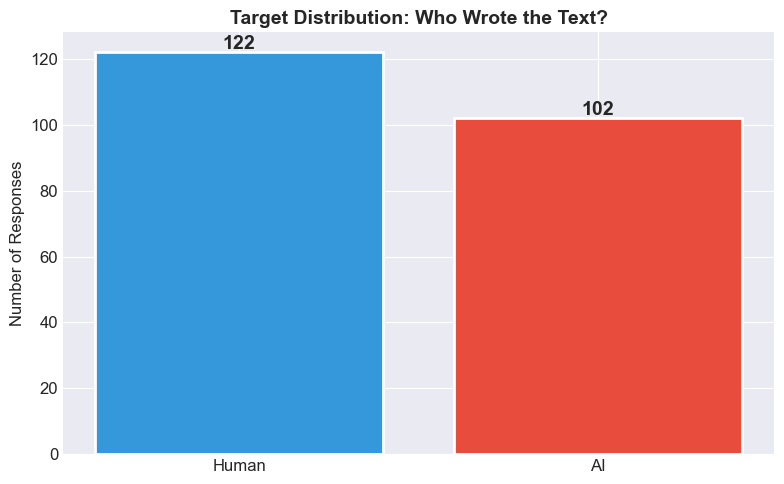

In [4]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c']
counts = df_model['target'].value_counts().sort_index()
bars = ax.bar(['Human', 'AI'], counts.values, color=colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=14, fontweight='bold')
ax.set_title('Target Distribution: Who Wrote the Text?', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Responses')
plt.tight_layout()
plt.savefig('media/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

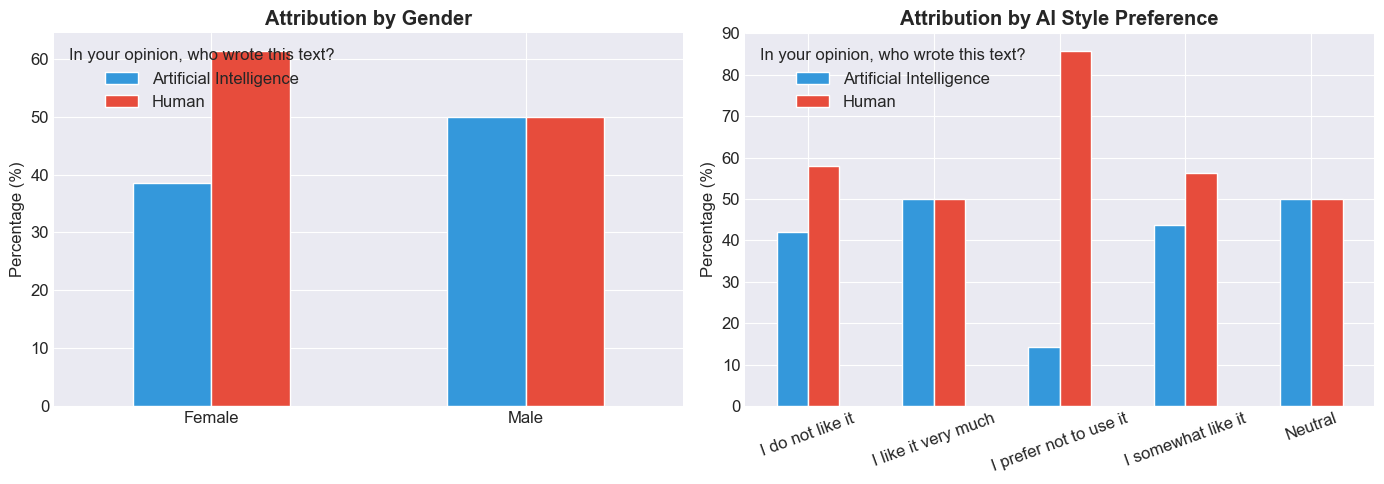

In [5]:
# How does AI style preference relate to text attribution?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Gender
ct1 = pd.crosstab(df_model['Gender'], df_model[target_col], normalize='index') * 100
ct1.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Attribution by Gender', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# By AI style preference
ct2 = pd.crosstab(df_model['Do you like the writing style of Artificial Intelligence (AI)?'],
                  df_model[target_col], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Attribution by AI Style Preference', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('media/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Prepare Features (Independent Variables)

We use the participant's other survey answers as **features** to predict their text attribution.

**Feature types:**
- **Demographics**: Gender, Age, Education, Field of Study
- **Opinions about AI**: Do they like AI writing? Is it repetitive? Can it convey emotions?
- **Ratings**: Creativity rating (1-5), Complex topics rating (1-5)
- **Multi-select questions**: We count how many options they selected

In [6]:
# === Feature Engineering ===

# 1. Ordinal features (convert text answers to numbers)
df_model['like_ai'] = df_model['Do you like the writing style of Artificial Intelligence (AI)?'].map({
    'I like it very much': 4, 'I somewhat like it': 3, 'Neutral': 2,
    'I do not like it': 1, 'I prefer not to use it': 0
})

df_model['repetitive'] = df_model['Do you feel that AI writing is sometimes repetitive or similar?'].map({
    'Always': 4, 'Often': 3, 'Sometimes': 2, 'Rarely': 1, 'Never': 0
})

df_model['emotion'] = df_model['Do you think AI can convey emotions in writing?'].map({
    'Yes, to a great extent': 3, 'Yes, to a moderate extent': 2,
    'To a limited extent': 1, 'No, it cannot convey emotions': 0
})

df_model['editing'] = df_model['Does AI writing need editing?'].map({
    'Always': 4, 'Often': 3, 'Sometimes': 2, 'Rarely': 1, 'Never': 0
})

# Clarity rating for text 2
df_model['clarity_text2'] = df_model['How would you rate the clarity and writing style of this   2'].map({
    'Very clear with a good style': 2, 'Moderately clear': 1, 'Not very clear': 0
})

# 2. Numerical features (already numbers)
df_model['complex_rating'] = pd.to_numeric(df_model['Rate AI writing when dealing with complex topics.'], errors='coerce')
df_model['creativity_rating'] = pd.to_numeric(df_model['How would you rate the creativity of AI-generated writing?'], errors='coerce')

# 3. Categorical features (convert categories to numbers)
cat_cols = ['Gender', "What's Your Age?", 'What is your current educational status?',
            'What is your field of study?', 'Which writing style gives you more trust?',
            'Do you think AI can be relied upon in writing?',
            'In your opinion, who wrote this text?   2',
            'Which writing style gives you more trust?   2']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

# 4. Multi-select features (count number of selections)
df_model['ai_advantages_count'] = df_model['What are the main advantages of using AI in writing?'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_model['human_distinctions_count'] = df_model['What most distinguishes human writing?'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_model['ai_tools_count'] = df_model['Which AI tools do you use for writing?'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

# === Define final feature list ===
feature_names = [
    'like_ai', 'repetitive', 'emotion', 'editing', 'clarity_text2',
    'complex_rating', 'creativity_rating',
    'ai_advantages_count', 'human_distinctions_count', 'ai_tools_count',
] + [col + '_enc' for col in cat_cols]

print(f'Total features: {len(feature_names)}')
print()
for i, name in enumerate(feature_names, 1):
    print(f'  {i:2d}. {name}')

Total features: 18

   1. like_ai
   2. repetitive
   3. emotion
   4. editing
   5. clarity_text2
   6. complex_rating
   7. creativity_rating
   8. ai_advantages_count
   9. human_distinctions_count
  10. ai_tools_count
  11. Gender_enc
  12. What's Your Age?_enc
  13. What is your current educational status?_enc
  14. What is your field of study?_enc
  15. Which writing style gives you more trust?_enc
  16. Do you think AI can be relied upon in writing?_enc
  17. In your opinion, who wrote this text?   2_enc
  18. Which writing style gives you more trust?   2_enc


---
## Step 6: Split Data into Training and Testing Sets

- **Training set (80%)**: The model learns from this data  
- **Testing set (20%)**: We test the model on data it has never seen before

In [7]:
# Prepare X (features) and y (target)
X = df_model[feature_names].fillna(0).values
y = df_model['target'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (normalize to same range)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Training set: 179 samples
Testing set:  45 samples


---
## Step 7: Train the Models

We train **two models** and compare them:

| Model | How it Works |
|-------|-------------|
| **Logistic Regression** | Finds a mathematical equation that separates AI from Human |
| **Random Forest** | Builds many decision trees and takes a vote from all of them |

In [8]:
# Define models
model_lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1, solver='liblinear', class_weight='balanced')
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=7)

# Cross-validation (test on different parts of training data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate Logistic Regression
cv_lr = cross_val_score(model_lr, X_train_scaled, y_train, cv=cv, scoring='accuracy')
model_lr.fit(X_train_scaled, y_train)
pred_lr = model_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, pred_lr)

# Train and evaluate Random Forest
cv_rf = cross_val_score(model_rf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
model_rf.fit(X_train_scaled, y_train)
pred_rf = model_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, pred_rf)

print('=== Results ===')
print(f'\nLogistic Regression:')
print(f'  CV Accuracy:   {cv_lr.mean():.2%} (+/- {cv_lr.std():.2%})')
print(f'  Test Accuracy: {acc_lr:.2%}')
print(f'\nRandom Forest:')
print(f'  CV Accuracy:   {cv_rf.mean():.2%} (+/- {cv_rf.std():.2%})')
print(f'  Test Accuracy: {acc_rf:.2%}')

# Pick the best model
if acc_rf >= acc_lr:
    best_model, best_name, best_pred, best_acc = model_rf, 'Random Forest', pred_rf, acc_rf
else:
    best_model, best_name, best_pred, best_acc = model_lr, 'Logistic Regression', pred_lr, acc_lr

print(f'\n>>> Best Model: {best_name} ({best_acc:.2%})')

=== Results ===

Logistic Regression:
  CV Accuracy:   69.25% (+/- 3.68%)
  Test Accuracy: 77.78%

Random Forest:
  CV Accuracy:   71.52% (+/- 5.30%)
  Test Accuracy: 82.22%

>>> Best Model: Random Forest (82.22%)


---
## Step 8: Evaluate the Best Model

### Classification Report
Shows how well the model performs for each class:
- **Precision**: Of all predictions for this class, how many were correct?
- **Recall**: Of all actual samples of this class, how many did we find?
- **F1-score**: Balance between precision and recall

In [9]:
print(f'Best Model: {best_name}')
print(f'Test Accuracy: {best_acc:.2%}')
print()
print(classification_report(y_test, best_pred, target_names=['Human', 'AI']))

Best Model: Random Forest
Test Accuracy: 82.22%

              precision    recall  f1-score   support

       Human       0.79      0.92      0.85        25
          AI       0.88      0.70      0.78        20

    accuracy                           0.82        45
   macro avg       0.83      0.81      0.81        45
weighted avg       0.83      0.82      0.82        45



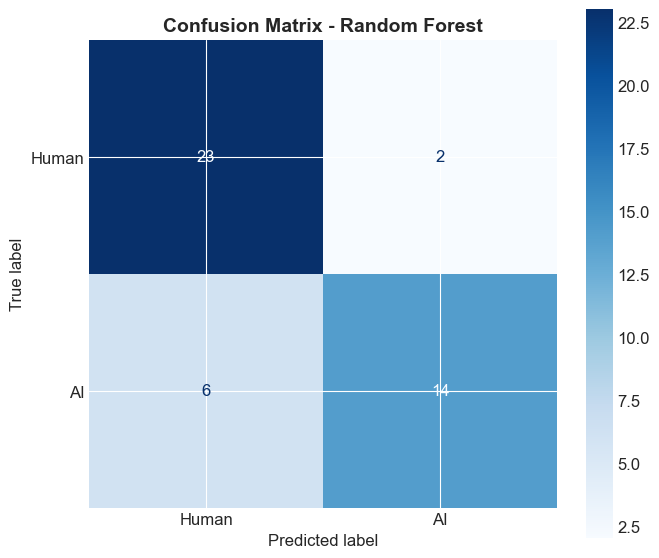

Correct predictions:   37 out of 45
  - Correctly predicted Human: 23
  - Correctly predicted AI:    14
Wrong predictions:     8
  - Said AI but was Human:     2
  - Said Human but was AI:     6


In [10]:
# Confusion Matrix: shows correct vs incorrect predictions
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=['Human', 'AI']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('media/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the matrix
tn, fp, fn, tp = cm.ravel()
print(f'Correct predictions:   {tn + tp} out of {len(y_test)}')
print(f'  - Correctly predicted Human: {tn}')
print(f'  - Correctly predicted AI:    {tp}')
print(f'Wrong predictions:     {fp + fn}')
print(f'  - Said AI but was Human:     {fp}')
print(f'  - Said Human but was AI:     {fn}')

---
## Step 9: Feature Importance

Which features had the **most influence** on the model's predictions?  
Higher importance = this feature matters more in deciding the outcome.

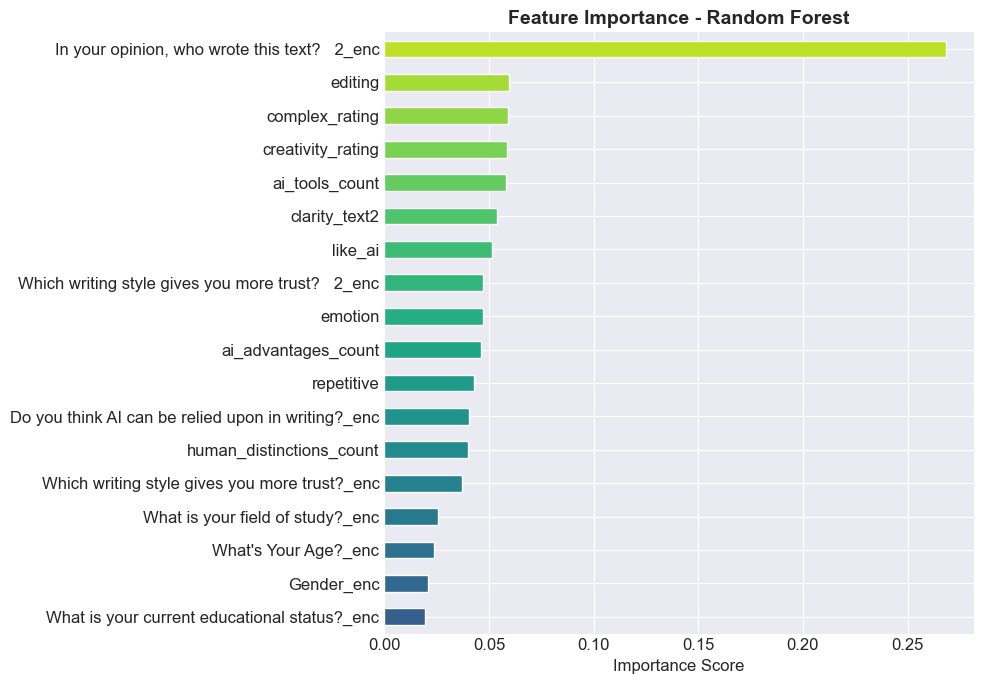

Top 5 most important features:
  1. In your opinion, who wrote this text?   2_enc: 0.2683
  2. editing: 0.0594
  3. complex_rating: 0.0591
  4. creativity_rating: 0.0588
  5. ai_tools_count: 0.0583


In [11]:
# Get feature importances from the best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

# Sort and plot
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title(f'Feature Importance - {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('media/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for i, (name, score) in enumerate(feat_imp.tail(5).iloc[::-1].items(), 1):
    print(f'  {i}. {name}: {score:.4f}')

---
## Step 10: Summary

In [12]:
print('=' * 50)
print('FINAL SUMMARY')
print('=' * 50)
print(f'''
Target Variable:
  "In your opinion, who wrote this text?"
  Human: {sum(y == 0)} | AI: {sum(y == 1)} | Total: {len(y)}

Model Used: {best_name}
  Test Accuracy: {best_acc:.2%}

What This Means:
  The model can correctly predict whether a person
  will think a text was written by AI or Human
  {best_acc:.0%} of the time, based on their survey answers.
''')

FINAL SUMMARY

Target Variable:
  "In your opinion, who wrote this text?"
  Human: 122 | AI: 102 | Total: 224

Model Used: Random Forest
  Test Accuracy: 82.22%

What This Means:
  The model can correctly predict whether a person
  will think a text was written by AI or Human
  82% of the time, based on their survey answers.

